**Data Patterns and Representations: Final Project** <br>
**2/24/2026** <br>
**Group 9:** Brooke Rice and Sadia Rahman

# Exploratory Data Analysis (EDA):

**Project Context** <br>
This project examines whether shifts in federal policy regimes are associated with structural changes in U.S. immigration enforcement outcomes between 2015 and 2025. Rather than focusing on raw totals, the analysis centers on the “repatriation to encounter” ratio as a measure of enforcement intensity. The goal is not to prove causation, but to evaluate whether observable structural differences in enforcement outcomes coincide with identifiable regime transitions such as administration changes and Title 42 activation.


**Numerical and Categorical Features** <br>
The DHS repatriations dataset mainly includes annual removal totals by fiscal year, along with several categorical breakdowns such as repatriation type, criminal vs non criminal status, arrest location, citizenship, and agency. For this EDA, the most important numerical variable is the annual repatriation total (quantity), since it represents the outcome side of immigration enforcement. These values are count based, meaning they are whole numbers and cannot be negative, and they show noticeable variation across fiscal years. This variability becomes clear in the Annual Repatriations line plot shown below, where we can see fluctuations over time rather than a stable pattern.<br>
The CBP encounters dataset, on the other hand, represents inflow pressure. Its main numerical variable is Encounter Count, which captures how many individuals were encountered in a given fiscal year. In addition to year level totals, this dataset includes several categorical dimensions such as Land Border Region, Area of Responsibility, State, Demographic category, Citizenship, Title of Authority, and Encounter Type. These categories help describe not just how many encounters occurred, but also under what legal authority and in which geographic or demographic context they occurred. The Annual Encounters line plot below shows a sharp increase beginning around FY2020, highlighting how dramatically inflow pressure changes during this period.<br>
Comparing the two visuals side by side reveals an important pattern. While encounters increase sharply after FY2020, repatriations do not rise at the same rate and eventually decline. This suggests that enforcement outcomes may not scale proportionally with encounter volume. Additionally, the categorical breakdown in the encounters dataset shows a clear distinction between Title 42 and Title 8 authority, which is important given the project’s focus on policy regimes. The Encounters by Title of Authority visualization further supports this by showing how legal authority shifts during peak encounter years, reinforcing the broader regime based framing described in the project proposal.

In [105]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style = "whitegrid")

In [2]:
# DHS Repatriations
dhs = pd.read_excel("KHSM Repatriations fy25m11.xlsx")

# CBP Encounters (combine multiple files)
enc1 = pd.read_excel("nationwide-encounters-fy20-fy23-aor.xlsx")
enc2 = pd.read_excel("nationwide-encounters-fy23-fy26-oct-aor.xlsx")
enc3 = pd.read_excel("nationwide-encounters-fy23-fy26-nov-aor.xlsx")
enc4 = pd.read_excel("nationwide-encounters-fy23-fy26-dec-aor.xlsx")
enc5 = pd.read_excel("nationwide-encounters-fy23-fy26-jan-aor.xlsx")

# Policy Markers
policy = pd.read_csv("policy_markers_2015_2025.csv")

In [348]:
dhs.keys()

dict_keys(['Annual Repatriations', 'Monthly Repatriations', 'Annual Repatriation Type', 'Monthly Repatriation Type', 'Annual Criminal', 'Monthly Criminal', 'Annual Arrest Location', 'Monthly Arrest Location', 'Annual Citizenship', 'Monthly Citizenship', 'Annual Repatriation Agency', 'Monthly Repatriation Agency', 'Annual Type & Dtl Type', 'Monthly Type & Dtl Type', 'Annual Type & Criminal', 'Monthly Type & Criminal', 'Annual Type & Arrest Loc', 'Monthly Type & Arr Loc', 'Annual Type & Citp', 'Monthly Type & Citp', 'Annual Typ & Rep Agency', 'Monthly Typ & Rep Agency'])

In [349]:
annual_repats = dhs["Annual Repatriations"]
annual_repats.columns

Index(['Fiscal\nYear', 'Quantity'], dtype='object')

(0.0, 1.5)

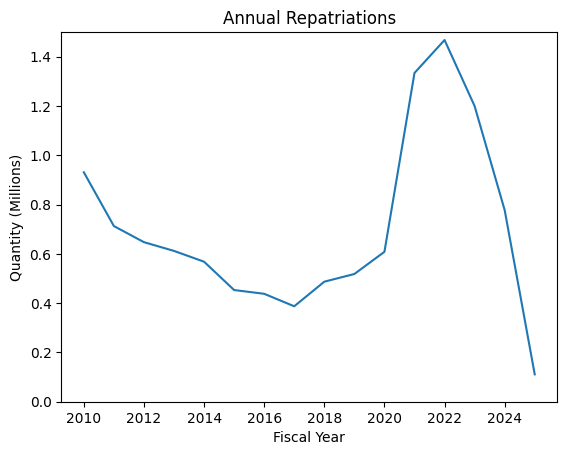

In [350]:
fig, ax = plt.subplots()
ax.plot(annual_repats["Fiscal\nYear"], annual_repats["Quantity"].apply(lambda x: x/1000000))
ax.set_title("Annual Repatriations")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Quantity (Millions)")
ax.set_ylim((0,1.5))

In [100]:
encounters2023 = pd.read_csv("nationwide-encounters-fy20-fy23-state.csv")
encounters2124 = pd.read_csv("nationwide-encounters-fy21-fy24-state.csv")
encounters2526 = pd.read_csv("nationwide-encounters-fy23-fy26-jan-state.csv")
encounters2526 = encounters2526[encounters2526["Fiscal Year"].apply(lambda x: ("2023" not in x) & ("2024" not in x))]
encounters2526["Fiscal Year"] = encounters2526["Fiscal Year"].apply(lambda x: 2025 if ("2025" in x) else 2026)

In [101]:
encounters = pd.concat([encounters2023, encounters2124,  encounters2526], axis=0)
encounters.columns

Index(['Fiscal Year', 'Month Grouping', 'Month (abbv)', 'Land Border Region',
       'State', 'Demographic', 'Citizenship', 'Title of Authority',
       'Encounter Count'],
      dtype='object')

In [374]:
encounters.head()

,Fiscal Year,Month Grouping,Month (abbv),Land Border Region,State,Demographic,Citizenship,Title of Authority,Encounter Count
0,2020,FYTD,APR,Northern Land Border,ID,Single Adults,CANADA,Title 8,2
1,2020,FYTD,APR,Northern Land Border,ME,Single Adults,CANADA,Title 42,2
2,2020,FYTD,APR,Northern Land Border,ME,Single Adults,CANADA,Title 8,153
3,2020,FYTD,APR,Northern Land Border,ME,Single Adults,"CHINA, PEOPLES REPUBLIC OF",Title 42,1
4,2020,FYTD,APR,Northern Land Border,ME,Single Adults,"CHINA, PEOPLES REPUBLIC OF",Title 8,0


In [375]:
yearly_encounters = encounters.groupby("Fiscal Year")["Encounter Count"].sum()

Text(0, 0.5, 'Quantity (Millions)')

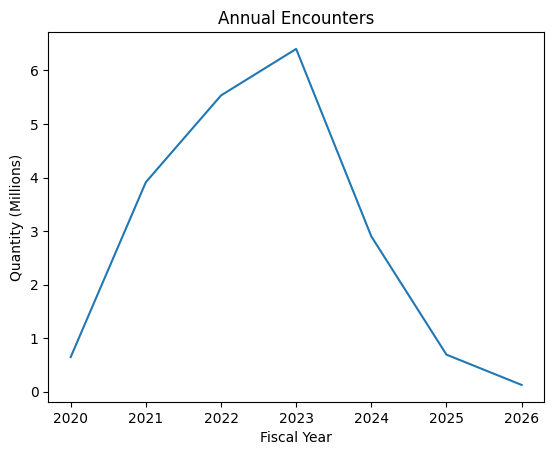

In [376]:
fig, ax = plt.subplots()
ax.plot(yearly_encounters.keys(), yearly_encounters.values/1000000)
ax.set_title("Annual Encounters")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Quantity (Millions)")

These establish the raw structure of the numerator and denominator.

**Construction of Enforcement Intensity Ratio and Basic Statistics** <br>
To move beyond raw totals, annual encounter totals were aggregated and merged with annual DHS repatriations to construct a “repatriation to encounter” ratio: <br>
$$
Ratio = {{Repatriations} \over {Encounters}}
$$
This ratio represents enforcement intensity (the share of encounters that result in repatriation).


**Summary Statistics for the Ratio**

In [29]:
dhs = dhs.rename(columns = {"Fiscal\nYear": "Fiscal Year"})
dhs["Fiscal Year"] = pd.to_numeric(dhs["Fiscal Year"], errors = "coerce").astype("Int64")

dhs.head(), dhs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Fiscal Year  16 non-null     Int64
 1   Quantity     16 non-null     int64
dtypes: Int64(1), int64(1)
memory usage: 404.0 bytes


(   Fiscal Year  Quantity
 0         2010    931170
 1         2011    712850
 2         2012    647530
 3         2013    612030
 4         2014    568250,
 None)

In [30]:
enc_fy = (enc1.groupby("Fiscal Year", as_index = False)["Encounter Count"]
          .sum()
          .rename(columns = {"Encounter Count": "Encounters_FY"})
         )

enc_fy.head(), enc_fy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Fiscal Year    4 non-null      int64
 1   Encounters_FY  4 non-null      int64
dtypes: int64(2)
memory usage: 196.0 bytes


(   Fiscal Year  Encounters_FY
 0         2020         646822
 1         2021        1956519
 2         2022        2766582
 3         2023        3201144,
 None)

In [31]:
fy = pd.merge(dhs.rename(columns = {"Quantity": "DHS_Quantity_FY"}),
              enc_fy,
              on = "Fiscal Year",
              how = "inner"
             )

fy["Repatriation_to_Encounter_Ratio"] = fy["DHS_Quantity_FY"] / fy["Encounters_FY"]
fy.sort_values("Fiscal Year").head(10)

,Fiscal Year,DHS_Quantity_FY,Encounters_FY,Repatriation_to_Encounter_Ratio
0,2020,608380,646822,0.940568
1,2021,1334210,1956519,0.681931
2,2022,1467940,2766582,0.530597
3,2023,1199910,3201144,0.374838


In [32]:
policy2 = policy.copy()
policy2["start_date"] = pd.to_datetime(policy2["start_date"], errors = "coerce")
policy2["end_date"] = pd.to_datetime(policy2["end_date"], errors = "coerce")

def fiscal_year(dt):
    # FY starts Oct 1: Oct-Dec belong to next FY
    return dt.year + (dt.month >= 10)

# create FY range per policy row
policy2["fy_start"] = policy2["start_date"].apply(fiscal_year)
policy2["fy_end"] = policy2["end_date"].apply(fiscal_year)

# explode into one row per FY
policy_fy = (policy2.loc[policy2["fy_start"].notna() & policy2["fy_end"].notna(),
             ["policy_id","policy_name","category","admin","fy_start","fy_end"]]
             .assign(Fiscal_Year_List = lambda d: d.apply(lambda r: list(range(int(r["fy_start"]), int(r["fy_end"]) + 1)), axis = 1))
             .explode("Fiscal_Year_List")
             .rename(columns = {"Fiscal_Year_List": "Fiscal Year"})
            )

policy_fy.head()

,policy_id,policy_name,category,admin,fy_start,fy_end,Fiscal Year
0,ADMIN_OBAMA,Administration: Barack Obama,administration,Obama,2015,2017,2015
0,ADMIN_OBAMA,Administration: Barack Obama,administration,Obama,2015,2017,2016
0,ADMIN_OBAMA,Administration: Barack Obama,administration,Obama,2015,2017,2017
1,ADMIN_TRUMP_1,Administration: Donald Trump (1st term),administration,Trump,2017,2021,2017
1,ADMIN_TRUMP_1,Administration: Donald Trump (1st term),administration,Trump,2017,2021,2018


In [33]:
fy_policy = fy.merge(policy_fy, on = "Fiscal Year", how = "left")
fy_policy.head(20)

,Fiscal Year,DHS_Quantity_FY,Encounters_FY,Repatriation_to_Encounter_Ratio,policy_id,policy_name,category,admin,fy_start,fy_end
0,2020,608380,646822,0.940568,ADMIN_TRUMP_1,Administration: Donald Trump (1st term),administration,Trump,2017,2021
1,2020,608380,646822,0.940568,NE_BORDER_2019,National Emergency Concerning the Southern Bor...,national_emergency,Trump/Biden,2019,2021
2,2020,608380,646822,0.940568,PHE_COVID,COVID-19 Public Health Emergency (HHS),public_health_emergency,Trump/Biden,2020,2023
3,2020,608380,646822,0.940568,TITLE42_MAIN,Title 42 border expulsions regime (CDC orders ...,border_enforcement_public_health,Trump/Biden,2020,2023
4,2020,608380,646822,0.940568,MPP_1,Migrant Protection Protocols (MPP 1.0 / 'Remai...,asylum_processing,Trump/Biden,2019,2021
5,2021,1334210,1956519,0.681931,ADMIN_TRUMP_1,Administration: Donald Trump (1st term),administration,Trump,2017,2021
6,2021,1334210,1956519,0.681931,ADMIN_BIDEN,Administration: Joe Biden,administration,Biden,2021,2025
7,2021,1334210,1956519,0.681931,NE_BORDER_2019,National Emergency Concerning the Southern Bor...,national_emergency,Trump/Biden,2019,2021
8,2021,1334210,1956519,0.681931,PHE_COVID,COVID-19 Public Health Emergency (HHS),public_health_emergency,Trump/Biden,2020,2023
9,2021,1334210,1956519,0.681931,TITLE42_MAIN,Title 42 border expulsions regime (CDC orders ...,border_enforcement_public_health,Trump/Biden,2020,2023


In [34]:
dhs_annual = dhs.rename(columns = {"Fiscal\nYear": "Fiscal Year", "Quantity": "Repatriations"})
dhs_annual["Fiscal Year"] = pd.to_numeric(dhs_annual["Fiscal Year"], errors = "coerce")

In [35]:
enc_annual = (enc1.groupby("Fiscal Year", as_index = False)["Encounter Count"] 
              .sum()
              .rename(columns = {"Encounter Count": "Encounters"})
             )

In [36]:
fy = pd.merge(dhs_annual, enc_annual, on = "Fiscal Year", how = "inner")
fy["Ratio"] = fy["Repatriations"] / fy["Encounters"]
fy.sort_values("Fiscal Year").head()

,Fiscal Year,Repatriations,Encounters,Ratio
0,2020,608380,646822,0.940568
1,2021,1334210,1956519,0.681931
2,2022,1467940,2766582,0.530597
3,2023,1199910,3201144,0.374838


In [107]:
fy_monthly = pd.merge(
    dhs_monthly[["Fiscal Year", "Month", "Repatriations"]],
    enc_annual[["Fiscal Year", "Encounters"]],
    on="Fiscal Year",
    how="inner"
)

fy_monthly["Ratio"] = fy_monthly["Repatriations"] / fy_monthly["Encounters"]

print("Rows in fy_annual:", len(fy_annual))
print("Rows in fy_monthly:", len(fy_monthly))
display(fy_monthly.head())

Rows in fy_annual: 4
Rows in fy_monthly: 48


,Fiscal Year,Month,Repatriations,Encounters,Ratio
0,2020,01 October,51360,646822,0.079404
1,2020,02 November,46120,646822,0.071302
2,2020,03 December,44920,646822,0.069447
3,2020,04 January,47060,646822,0.072756
4,2020,05 February,48730,646822,0.075338


In [37]:
policy = pd.read_csv("policy_markers_2015_2025.csv")
policy["start_date"] = pd.to_datetime(policy["start_date"], errors = "coerce")
policy["end_date"] = pd.to_datetime(policy["end_date"], errors = "coerce")

def fiscal_year(dt):
    # FY starts Oct 1 
    return dt.year + (dt.month >= 10)

policy["fy_start"] = policy["start_date"].apply(fiscal_year)
policy["fy_end"] = policy["end_date"].apply(fiscal_year)

policy_fy = (policy.dropna(subset=["fy_start","fy_end"])
             .assign(Fiscal_Year_List = lambda d: d.apply(lambda r: list(range(int(r["fy_start"]), int(r["fy_end"]) + 1)), axis = 1))
             .explode("Fiscal_Year_List")
             .rename(columns={"Fiscal_Year_List":"Fiscal Year"})
            )

policy_fy = policy_fy[["Fiscal Year","admin","category","policy_name","policy_id"]]
policy_fy.head()

,Fiscal Year,admin,category,policy_name,policy_id
0,2015,Obama,administration,Administration: Barack Obama,ADMIN_OBAMA
0,2016,Obama,administration,Administration: Barack Obama,ADMIN_OBAMA
0,2017,Obama,administration,Administration: Barack Obama,ADMIN_OBAMA
1,2017,Trump,administration,Administration: Donald Trump (1st term),ADMIN_TRUMP_1
1,2018,Trump,administration,Administration: Donald Trump (1st term),ADMIN_TRUMP_1


In [38]:
fy_policy = fy.merge(policy_fy, on = "Fiscal Year", how = "left")

In [39]:
repat_stats = dhs_annual["Repatriations"].agg(["count", "mean", "median", "std", "min", "max"])
repat_stats

count     1.600000e+01
mean      7.034331e+05
median    6.102050e+05
std       3.642389e+05
min       1.110100e+05
max       1.467940e+06
Name: Repatriations, dtype: float64

In [40]:
repat_stats_df = repat_stats.to_frame(name = "Repatriations")
repat_stats_df

,Repatriations
count,1.600000e+01
mean,7.034331e+05
median,6.102050e+05
std,3.642389e+05
min,1.110100e+05
max,1.467940e+06


In [41]:
enc_stats = enc_annual["Encounters"].agg(["count", "mean", "median", "std", "min", "max"])
enc_stats_df = enc_stats.to_frame(name = "Encounters")
enc_stats_df

,Encounters
count,4.000000e+00
mean,2.142767e+06
median,2.361550e+06
std,1.122771e+06
min,6.468220e+05
max,3.201144e+06


In [42]:
ratio_stats = fy["Ratio"].agg(["count", "mean", "median", "std", "min", "max"])
ratio_stats_df = ratio_stats.to_frame(name = "Repatriation_to_Encounter_Ratio")
ratio_stats_df

,Repatriation_to_Encounter_Ratio
count,4.000000
mean,0.631983
median,0.606264
std,0.240916
min,0.374838
max,0.940568


In [43]:
dhs_annual["Repatriations_k"] = dhs_annual["Repatriations"] / 1_000
enc_annual["Encounters_k"] = enc_annual["Encounters"] / 1_000

In [44]:
summary_table = pd.DataFrame({"Repatriations (thousands)": dhs_annual["Repatriations_k"].agg(["mean", "median", "std", "min", "max"]),
                              "Encounters (thousands)": enc_annual["Encounters_k"].agg(["mean", "median", "std", "min", "max"]),
                              "Ratio": fy["Ratio"].agg(["mean", "median", "std", "min", "max"])
                             })

summary_table.round(3)

,Repatriations (thousands),Encounters (thousands),Ratio
mean,703.433,2142.767,0.632
median,610.205,2361.550,0.606
std,364.239,1122.771,0.241
min,111.010,646.822,0.375
max,1467.940,3201.144,0.941


The relatively large standard deviation indicates meaningful variability across fiscal years. Most notably, the ratio declines steadily even as raw encounter volume increases dramatically. <br>
This confirms that enforcement output does not scale proportionally with inflow pressure.

In [88]:
enc_annual = (enc1.groupby("Fiscal Year", as_index = False)["Encounter Count"]
              .sum()
              .rename(columns = {"Encounter Count": "Encounters"})
             )

print(enc_annual["Fiscal Year"].unique())
enc_annual.head()

[2020 2021 2022 2023]


,Fiscal Year,Encounters
0,2020,646822
1,2021,1956519
2,2022,2766582
3,2023,3201144


In [90]:
dhs_month = pd.read_excel("KHSM Repatriations fy25m11.xlsx",
                          sheet_name = "Monthly Repatriations"
                         )

# clean column names
dhs_month.columns = (dhs_month.columns.astype(str)
                     .str.replace("\n", " ", regex = False)
                     .str.replace(r"\s+", " ", regex = True)
                     .str.strip()
                    )

print(dhs_month.columns)
dhs_month.head()

Index(['Fiscal Year', 'Month', 'Quantity'], dtype='object')


,Fiscal Year,Month,Quantity
0,2010,01 October,79200
1,2010,02 November,69680
2,2010,03 December,63560
3,2010,04 January,69200
4,2010,05 February,75750


In [91]:
# find likely columns
fy_col = [c for c in dhs_month.columns if "Fiscal" in c][0]
qty_col = [c for c in dhs_month.columns if "Quantity" in c][0]
month_col = [c for c in dhs_month.columns if "Month" in c][0]

dhs_monthly = dhs_month.rename(columns = {fy_col: "Fiscal Year",
                                        month_col: "Month",
                                        qty_col: "Repatriations"
                                       }).copy()

# make sure FY numeric
dhs_monthly["Fiscal Year"] = pd.to_numeric(dhs_monthly["Fiscal Year"], errors = "coerce")

# keep only rows with actual data
dhs_monthly = dhs_monthly.dropna(subset=["Fiscal Year", "Month", "Repatriations"])

print("DHS monthly rows:", len(dhs_monthly))
dhs_monthly.head()

DHS monthly rows: 182


,Fiscal Year,Month,Repatriations
0,2010,01 October,79200
1,2010,02 November,69680
2,2010,03 December,63560
3,2010,04 January,69200
4,2010,05 February,75750


In [92]:
fy_monthly = pd.merge(
    dhs_monthly[["Fiscal Year", "Month", "Repatriations"]],
    enc_annual[["Fiscal Year", "Encounters"]],
    on="Fiscal Year",
    how="inner"
)

fy_monthly["Ratio"] = fy_monthly["Repatriations"] / fy_monthly["Encounters"]

print("fy_monthly rows:", len(fy_monthly))
print(fy_monthly["Fiscal Year"].value_counts())
fy_monthly.head()

fy_monthly rows: 48
Fiscal Year
2020    12
2021    12
2022    12
2023    12
Name: count, dtype: int64


,Fiscal Year,Month,Repatriations,Encounters,Ratio
0,2020,01 October,51360,646822,0.079404
1,2020,02 November,46120,646822,0.071302
2,2020,03 December,44920,646822,0.069447
3,2020,04 January,47060,646822,0.072756
4,2020,05 February,48730,646822,0.075338


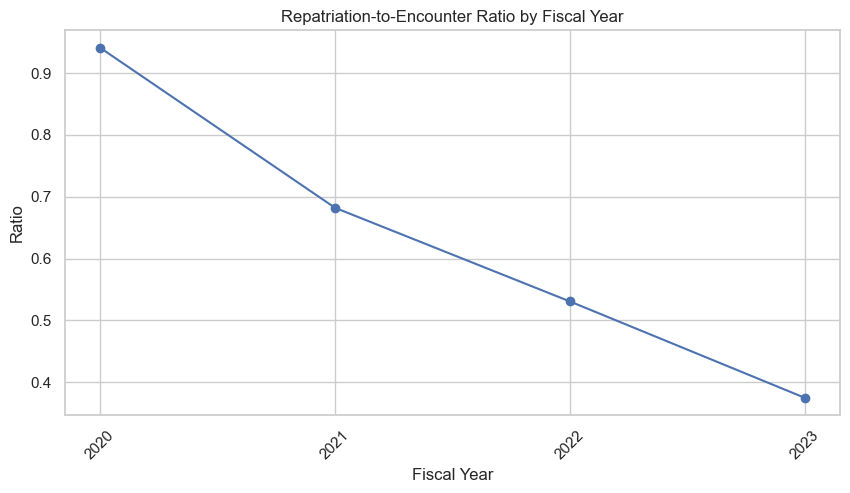

In [97]:
fy_sorted = fy.sort_values("Fiscal Year")

plt.figure(figsize = (10,5))
plt.plot(fy_sorted["Fiscal Year"], fy_sorted["Ratio"], marker = "o")
plt.title("Repatriation-to-Encounter Ratio by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Ratio")
plt.xticks(fy_sorted["Fiscal Year"], rotation = 45)
plt.show()

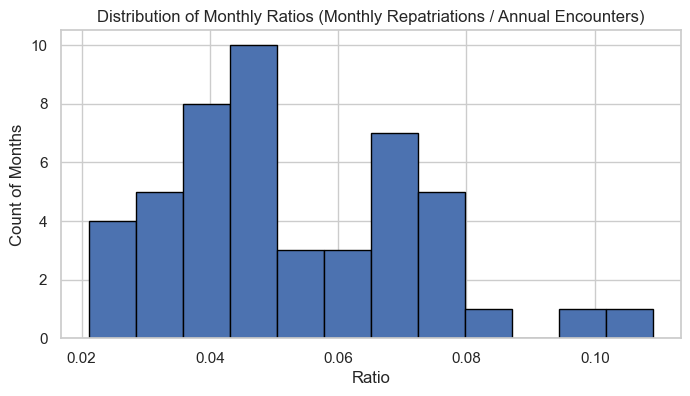

In [96]:
plt.figure(figsize = (8,4))
plt.hist(fy_monthly["Ratio"].dropna(), bins = 12, edgecolor = "black")
plt.title("Distribution of Monthly Ratios (Monthly Repatriations / Annual Encounters)")
plt.xlabel("Ratio")
plt.ylabel("Count of Months")
plt.show()

In [58]:
print(fy[["Repatriations", "Encounters", "Ratio"]])

   Repatriations  Encounters     Ratio
0         608380      646822  0.940568
1        1334210     1956519  0.681931
2        1467940     2766582  0.530597
3        1199910     3201144  0.374838


**Structural Patterns and Regime Differences** <br>
The Ratio by Fiscal Year line plot shows a clear downward trend starting around FY2020. Even though repatriations increase at first, they do not keep up with the rapid growth in encounters. As encounters surge, the ratio steadily declines, meaning a smaller share of encounters results in repatriation over time. This creates a noticeable gap between inflow pressure (encounters) and enforcement output (repatriations). The visual makes this pattern much easier to see than looking at raw numbers alone.<br>
To explore whether these changes might be connected to broader institutional shifts, a boxplot of the ratio by administration was created. The boxplot shows that enforcement intensity is not evenly distributed across administrations. Instead, the ratio varies in level and spread depending on the time period. This suggests that enforcement outcomes may be influenced by broader regime conditions, not just by how many people are encountered at the border.<br>
The Encounters by Title of Authority visualization adds another layer to this analysis. It shows how the use of Title 42 and Title 8 changes over time, especially during peak encounter years. Since Title 42 represents a major legal mechanism during the public health emergency period, shifts in authority likely affect how encounters are processed. Seeing these authority changes alongside the declining ratio provides additional context for why enforcement intensity may be shifting.<br>
Overall, these visuals support the project’s main objective, where instead of focusing only on raw totals, the analysis looks for structural differences in enforcement intensity that align with broader policy regimes. The patterns in the ratio line plot, administration boxplot, and authority breakdown together suggest that enforcement dynamics change across institutional environments rather than remaining constant over time.

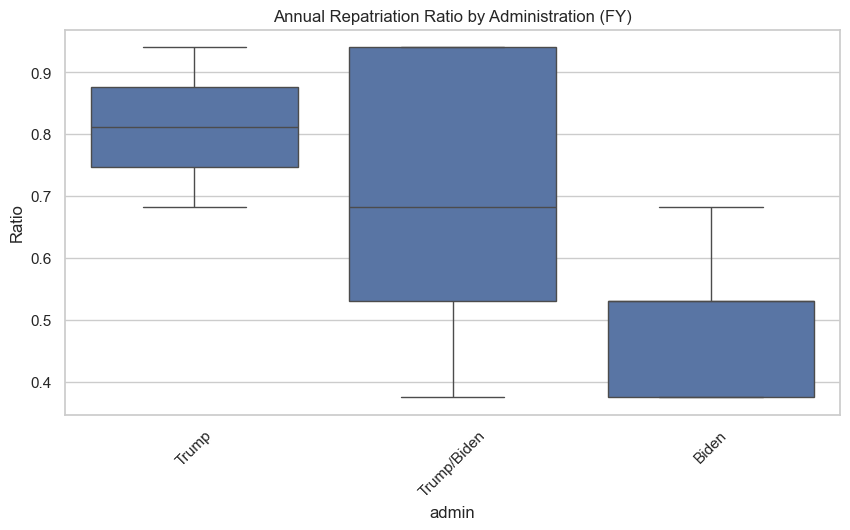

In [71]:
plt.figure(figsize = (10,5))
sns.boxplot(data = fy_policy, x = "admin", y = "Ratio")
plt.title("Annual Repatriation Ratio by Administration (FY)")
plt.xticks(rotation = 45)
plt.show()

Text(0.5, 0.01, 'Fiscal Year')

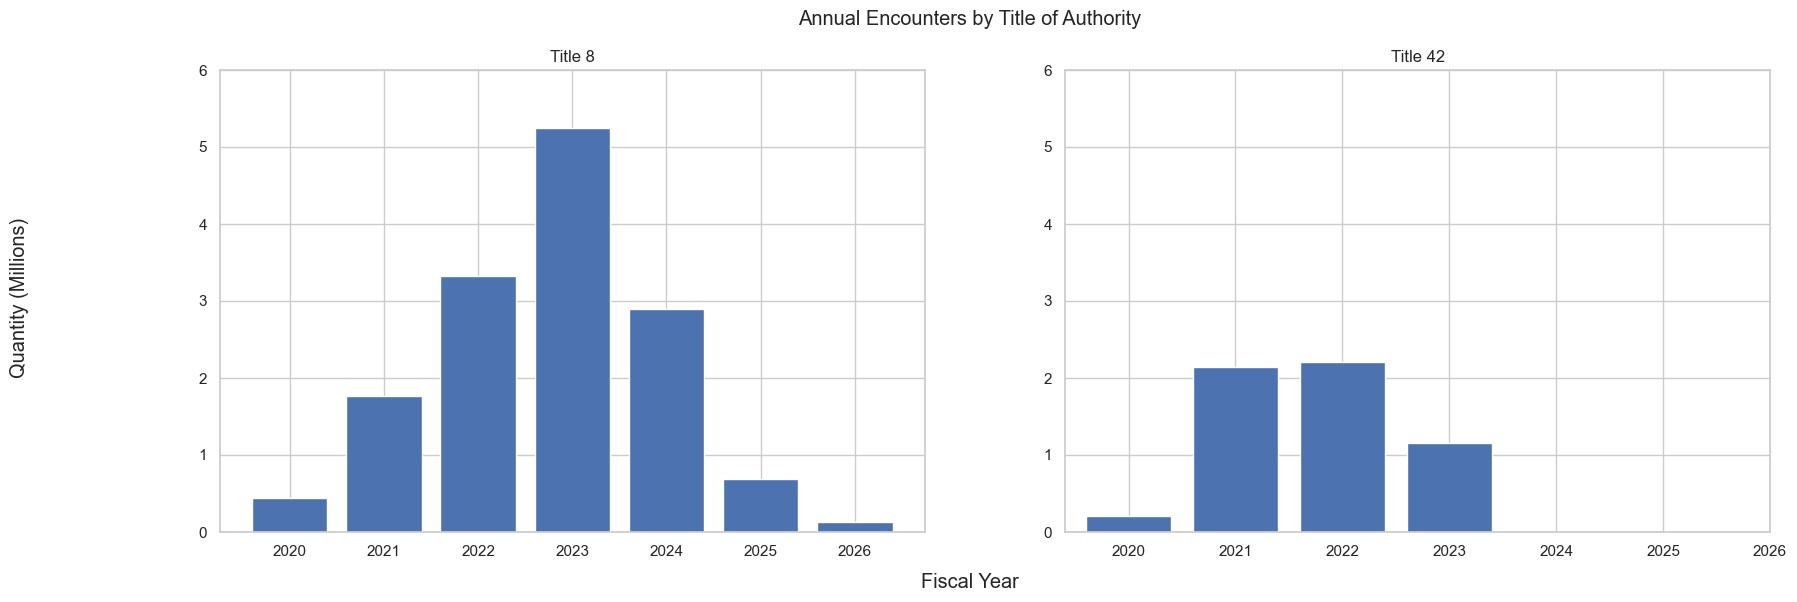

In [106]:
formatter = matplotlib.ticker.StrMethodFormatter("{x:.0f}")
figure = plt.figure(figsize=(20, 6))

authorities = encounters["Title of Authority"].unique()

for i, authority in enumerate(authorities):
    axes = figure.add_subplot(1, len(authorities), i+1)
    authority_encounters = encounters[encounters["Title of Authority"] == authority].groupby("Fiscal Year")["Encounter Count"].sum()
    axes.bar(authority_encounters.keys(), authority_encounters.values/1000000)
    axes.set_title(f"{authority}")
    axes.set_ylim((0,6))
    axes.set_xticks(range(2020, 2027))
    plt.gca().xaxis.set_major_formatter(formatter)

figure.suptitle("Annual Encounters by Title of Authority")
figure.supylabel("Quantity (Millions)")
figure.supxlabel("Fiscal Year")

**Scaling Behavior and Capacity Constraints** <br>
To better understand how encounter volume relates to enforcement outcomes, a scatter plot comparing Encounters and Repatriations was created. This visualization helps show whether removals increase at the same rate as inflow pressure or if the relationship changes as encounters rise. 
The scatter plot shows that repatriations do generally increase as encounters increase, but the relationship is not proportional. At lower encounter levels, repatriations appear more tightly clustered. However, as encounters reach higher levels, the spread in repatriation totals becomes much wider. This means enforcement output becomes less predictable during peak inflow periods. In other words, the system does not seem to operate at a constant processing rate. Instead of scaling evenly with encounter growth, repatriations fluctuate more as pressure increases. <br>
This pattern suggests that enforcement intensity may decline during periods of rapid encounter growth. When encounters surge, the share that results in repatriation appears to fall, which could reflect operational capacity limits, legal constraints, or broader institutional shifts. Rather than simply reflecting higher volume, the relationship between encounters and removals seems sensitive to structural conditions. <br>
This directly connects to one of the additional research questions outlined in the project proposal, which is whether periods of rapid encounter growth correspond with declining repatriation ratios, potentially indicating operational capacity constraints 
The scatter plot provides early exploratory evidence that such a relationship may exist and warrants further structural analysis.


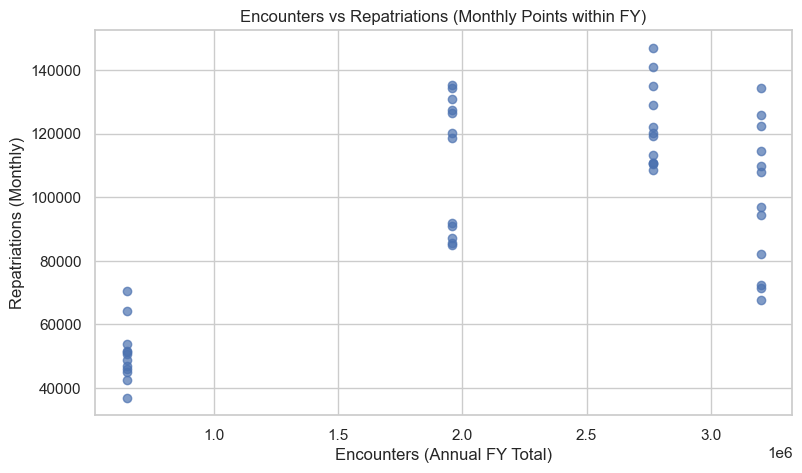

In [95]:
plt.figure(figsize = (9,5))
plt.scatter(fy_monthly["Encounters"], fy_monthly["Repatriations"], alpha = 0.7)
plt.xlabel("Encounters (Annual FY Total)")
plt.ylabel("Repatriations (Monthly)")
plt.title("Encounters vs Repatriations (Monthly Points within FY)")
plt.show()

***Refinement of Research Questions** <br>
The initial question asked whether changes in repatriation ratios are associated with identifiable federal policy regime shifts. After examining the visuals and summary statistics, it is clear that the ratio does not remain stable over time. Instead, it shows noticeable structural movement beginning around FY2020, which suggests that something broader than random fluctuation may be occurring.<br>
The ratio line plot, boxplot by administration, and scatter plot together show that enforcement intensity is not constant and does not scale proportionally with encounter volume. As encounters increase sharply, the share resulting in repatriation declines. This suggests that enforcement output may be influenced by institutional conditions rather than simply by inflow pressure alone.<br>
Based on these findings, the research focus shifts slightly. Instead of only asking whether regime shifts are associated with changes in the ratio, the analysis now considers more specific questions: <br>
-	Does enforcement intensity decline during high volume encounter periods? <br>
-	Do legal regime shifts, such as the implementation of Title 42, alter the relationship between encounters and removals? <br>
-	Are observable structural breaks in the ratio aligned with administration transitions? <br>
-	Does enforcement variability increase during emergency or public health periods? <br>
The EDA results suggest that enforcement dynamics are sensitive to regime context. Rather than comparing raw counts alone, the next stage of analysis should focus on structural classification of policy periods and testing for regime aligned shifts in enforcement intensity. This approach remains consistent with the project’s objective of identifying structural differences across enforcement environments